# Zero-Train Optimization & Maintenance (ZTOM) of a Legal Understanding LLM


----
## The Problem


> Every time you fine-tune a model for a new task, you risk breaking existing capabilities. 
> Fixing that usually means **retraining** — which is expensive, slow, and hard to debug.


This demo shows how you can use Authentrics and solve it **without retraining**.

### Impact of Continuous Training on Models
1. Task Interference: Learning to perform one task decrease the performance on others even if trained together or sequentially,leading to unstable finetuning,conflicting gradients and reduced speciailization.[cited](https://arxiv.org/abs/2603.18425)
2. Catastrophic Forgetting : Models learning new task overwrites previous knowledge. [cited](https://arxiv.org/abs/2308.08747).




---


## Demo Scenario


We walk through a realistic production scenario:


1. Train a model for **legal contract understanding** 
2. Add a new capability (**summarization**) 
3. Observe **regression in the original task** 
4. Detect *where and how* the model changed 
5. Fix the issue using **ZTOM — no retraining required**


---


## Model Setup


- **Base model:** [Gemma 3 1B IT](https://huggingface.co/google/gemma-3-1b-it) — (instruction-tuned)
- **Adaptation:** LoRA adapters via [Hugging Face PEFT](https://huggingface.co/docs/peft) 
- **Why this setup:**
 - Efficient fine-tuning
 - Standard industry approach
 - Enables clean comparison across checkpoints


---


## Fine-Tuning Tasks


### Task A — Contract Understanding (Primary Capability)


- Dataset: : CUAD as QA over contracts; [CUAD paper](https://arxiv.org/abs/2103.06268). 
- Objective: Answer questions over legal contracts 


---


### Task B — Legal Bill Summarization (New Capability)


- Dataset: :[BillSum](https://huggingface.co/datasets/billsum) — long bills with human summaries.
- Objective: Generate concise summaries from long Legal Documents 
- Evaluation: ROUGE (ROUGE-1 / ROUGE-L)


---
### Impact of Task B training on Task A (TODO: Modify the stats or image accordingly)
![image.png](attachment:image.png)






## Why This Matters


In production systems:


- Models are **continuously updated** with new capabilities 
- Each update risks **silent regressions** 
- Retraining:
 - ❌ expensive (GPU + time)
 - ❌ non-deterministic
 - ❌ no visibility into *what actually changed*


**This is the gap ZTOM addresses**.


---


## What is ZTOM?


**Zero-Train Optimization & Maintenance (ZTOM)** directly adjusts a model’s behavior:


- ✅ No retraining
- ✅ No additional data required 
- ✅ Works on existing checkpoints 
- ✅ Targets *specific behavioral drift*


Instead of:
> “Retrain the entire model and hope it improves”


We:
> “Identify the exact change and correct it”


---


## Optimization Objective


Authentrics optimizes using **custom loss function** and **small sample of datasets** that is given by the user:
In this demo, the optimization objective is to improve the latest model for CUAD accuracy
while maintaining the accuracy for bill summarization post training.


- Metric: Mean RapidFuzz `partial_ratio` 
- Compared against: `dataset["answer"]` 
- Goal: **maximize similarity** (`minimize=False`)


---


## 📈 Results


ZTOM improves model performance **without retraining**:
TODO: Benchmark values ,
Total training time vs ZTOM
Training gpu used(2 L4s) vs ZTOM(1 L4)
Number of datasets(Training vs ZTOM)
 




| Metric | Value |
|--------|------:|
| **Objective** | Mean RapidFuzz `partial_ratio` vs. `dataset["answer"]` (higher is better) |
| **Optimizer** | `minimize=False` (maximize objective) |
| **Scaling factors** | `[-0.262, 0.084, 0.999, -0.614, -0.226, 0.765, -0.215, 0.577, 0.276]` |
| **Original objective** | 31.227872848510742 |
| **Best objective** | 59.72260665893555 |
| **Relative improvement** | ~91% vs. original \((\text{best}-\text{original})/\text{original}\) |
| **Number of evaluations** | 100 |
---


## 💡 Key Takeaway


> We are not retraining the model. 
> We are **correcting it**.


ZTOM enables:
- Faster iteration cycles 
- Lower infrastructure cost 
- Precise control over model behavior 


---


## 🧠 (Optional Deep Dive — for advanced users)


Under the hood:
- Layer-level changes are analyzed across checkpoints 
- Optimization targets specific behavioral deltas 
- Scaling factors are applied selectively across model components 


This detail is **not required to use the system**, but available for deeper inspection.


## AuthentricsSession — main client


The primary object for talking to the Authentrics service: authentication, projects, checkpoints, and analyses. Set `session.model` to a `ModelInterface` implementation before running analyses.


**Used:** ✓ marks members called in this notebook (optional cleanup paths included).


| Used | Member | Description | Returns / side effects |
|------|--------|-------------|-------------------------|
| ✓ | `AuthentricsSession()` | Construct a new session. | |
| ✓ | `login()` | Prompt for credentials and sign in. | |
| | `login(username, password)` | Sign in with explicit credentials. | |
| | `base_url` (property) | Get/set the API base URL. | For custom or non-default servers. |
| ✓ | `model` (property) | Get/set the `ModelInterface` used for all analysis operations. | Must be set before analyses. |
| ✓ | `get_projects()` | List all projects for the authenticated user. | `list[Project]`. |
| ✓ | `load_project(project_path='.')` | Load a project from a directory (or subdirectory of a project). | `Project`. |
| ✓ | `create_project(new_project_path, name, description='')` | Create a project in a **new** directory. | `Project`. |
| | `init_project(project_path, name, description='')` | Initialize a project in an **existing** directory. | `Project`. |
| | `update_project(project)` | Persist project field updates locally and on the server. | Updated `Project`. |
| ✓ | `delete_project(project)` | Remove the project locally and on the server. | `None`. |
| ✓ | `add_checkpoints(project, *checkpoint_paths)` | Register additional checkpoint files with the project. | Updated `Project`. |
| | `delete_checkpoints(project, *checkpoints)` | Remove checkpoints from the project. | Updated `Project`. |
| | `update_checkpoint(project_path, checkpoint, update_hash=False)` | Update checkpoint metadata (e.g. name, path); optionally refresh hash. | Updated `Project`. |
| | `static_analysis(project, previous_checkpoint_path, chosen_checkpoint_path, weight_names=None, bias_names=None)` | Compare weights/biases between two checkpoints (standard and relative differences). | `StaticAnalysisResult`. |
| | `comparative_analysis(project, previous_checkpoint_path, chosen_checkpoint_path, layer_names=None)` | Compare checkpoints including intermediate layer outputs. | `ComparativeAnalysisResult`. |
| | `correlation_analysis(project, previous_checkpoint_path, chosen_checkpoint_path, layer_names, reference_layer_name)` | Correlations between model outputs and layer outputs for both checkpoints. | `CorrelationAnalysisResult`. |
| | `exclude_training(project, checkpoint_pairs, latest_checkpoint_path, new_checkpoint_path)` | Remove effects of selected training intervals (before/after pairs) from the latest checkpoint; writes a new checkpoint. | `ExcludeTrainingResult`. |
| ✓ | `ztom_analysis(project, loss_function, new_checkpoint_path, optimization_options=...)` | Zero-train optimization / maintenance: optimize sequential checkpoints against a scalar loss on model output. | `ZtomAnalysisResult`. |

### Install dependencies and utility functions: This cell should be run once.

In [1]:
%%capture
%pip install -r requirements.txt
%pip install 'authentrics==0.21.2' --extra-index-url='https://us-central1-python.pkg.dev/authentrics/authentrics/simple'

### Setup utility functions: This cell should be run once.

In [2]:
import torch
from __future__ import annotations
from authentrics import AuthentricsSession
from dotenv import load_dotenv
from tokenizers import Tokenizer
from pathlib import Path
from typing import Optional, Any
from peft import PeftModel
from rapidfuzz import fuzz
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline
import matplotlib.pyplot as plt


load_dotenv()

def cleanup_project(session: AuthentricsSession, project_name: str):
    print("Cleaning up project: ", project_name)
    if Path(project_name).exists():
        try:
            projects = session.get_projects()
            print("Projects: found")
            for project in projects:
                if project.name == project_name:
                    session.delete_project(project)
                    print("Project: deleted")
                    Path(project_name).rmdir()
                    print("Project: removed")
                    return
        except Exception as e:
            print("Error: ", e)
            Path(project_name).rmdir()


def format_row(tokenizer: Tokenizer, example):
    messages = [
        {
            "role": "user",
            "content": (
                "Answer the legal question based on the contract.\n\n"
                f"Question: {example['question']}\n\n"
                f"Context:\n{example['context']}"
            ),
        },
    ]
    example["formatted_chat"] = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    return example

def _format_cuad_dataset(dataset, tokenizer, use_base_prompt: bool):
    def format_row(example):
        if use_base_prompt:
            instruction = (
                "Answer the legal question based on the contract.\n"
                "Respond with only the answer phrase."
            )
        else:
            instruction = "Answer the legal question based on the contract."

        example["formatted_chat"] = tokenizer.apply_chat_template(
            [
                {
                    "role": "user",
                    "content": (
                        f"{instruction}\n\n"
                        f"Question: {example['question']}\n\n"
                        f"Context:\n{example['context']}"
                    ),
                }
            ],
            tokenize=False,
            add_generation_prompt=True,
        )
        return example

    return dataset.map(format_row)


def _format_bill_sum_dataset(dataset, tokenizer):
    def format_row(example):
        return {
            "formatted_chat": tokenizer.apply_chat_template(
                [
                    {
                        "role": "user",
                        "content": f"Summarize the document.\n\nContext:\n{example['text']}",
                    }
                ],
                tokenize=False,
                add_generation_prompt=True,
            ),
            "summary": example["summary"],
        }

    return dataset.map(format_row, remove_columns=dataset.column_names)


def clean_answer(text):
    if "<start_of_turn>model" in text:
        text = text.split("<start_of_turn>model")[-1]

    return text.strip()


def _tokenize(text: str) -> list[str]:
    return text.lower().split()


def _lcs_length(a: list[str], b: list[str]) -> int:
    if not a or not b:
        return 0

    prev = [0] * (len(b) + 1)
    for token_a in a:
        curr = [0] * (len(b) + 1)
        for j, token_b in enumerate(b, start=1):
            if token_a == token_b:
                curr[j] = prev[j - 1] + 1
            else:
                curr[j] = max(prev[j], curr[j - 1])
        prev = curr
    return prev[-1]


def _rouge_l_scores(prediction: str, reference: str) -> dict[str, float]:
    pred_tokens = _tokenize(prediction)
    ref_tokens = _tokenize(reference)
    if not pred_tokens or not ref_tokens:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    lcs = _lcs_length(pred_tokens, ref_tokens)
    precision = lcs / len(pred_tokens)
    recall = lcs / len(ref_tokens)
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = (2 * precision * recall) / (precision + recall)

    return {"precision": precision, "recall": recall, "f1": f1}


def evaluate_qa_model(pipe, dataset, num_samples: Optional[int] = None, max_new_tokens: int = 1024):
    correct = 0
    total = 0
    partial_ratio_sum = 0.0
    exact_match_count = 0

    for i, row in enumerate(dataset):
        if num_samples and i >= num_samples:
            break

        prompt = row["formatted_chat"]
        gold = row["answer"]

        result = pipe(prompt, max_new_tokens=max_new_tokens, do_sample=False, return_full_text=False)
        generated = result[0]["generated_text"]

        pred = clean_answer(generated)
        score = fuzz.partial_ratio(pred.lower(), gold.lower())

        partial_ratio_sum += score
        if pred.lower() == gold.lower():
            exact_match_count += 1
        if score >= 90:
            correct += 1
        total += 1

    if total == 0:
        return {
            "analysis_accuracy": 0.0,
            "analysis_exact_match": 0.0,
            "analysis_avg_partial_ratio": 0.0,
            "analysis_samples": 0.0,
        }

    return {
        "analysis_accuracy": correct / total,
        "analysis_exact_match": exact_match_count / total,
        "analysis_avg_partial_ratio": partial_ratio_sum / total,
        "analysis_samples": float(total),
    }


def evaluate_summarization_model(
    pipe,
    dataset,
    num_samples: Optional[int] = None,
    max_new_tokens: int = 1024,
):
    total = 0
    rouge_l_precision_sum = 0.0
    rouge_l_recall_sum = 0.0
    rouge_l_f1_sum = 0.0
    partial_ratio_sum = 0.0

    for i, row in enumerate(dataset):
        if num_samples and i >= num_samples:
            break

        prompt = row["formatted_chat"]
        gold = row["summary"]

        result = pipe(prompt, max_new_tokens=max_new_tokens, do_sample=False, return_full_text=False)
        generated = result[0]["generated_text"]

        pred = clean_answer(generated)
        rouge_scores = _rouge_l_scores(pred, gold)

        rouge_l_precision_sum += rouge_scores["precision"]
        rouge_l_recall_sum += rouge_scores["recall"]
        rouge_l_f1_sum += rouge_scores["f1"]
        partial_ratio_sum += fuzz.partial_ratio(pred.lower(), gold.lower())
        total += 1

    if total == 0:
        return {
            "analysis_rouge_l_precision": 0.0,
            "analysis_rouge_l_recall": 0.0,
            "analysis_rouge_l_f1": 0.0,
            "analysis_avg_partial_ratio": 0.0,
            "analysis_samples": 0.0,
        }

    return {
        "analysis_rouge_l_precision": rouge_l_precision_sum / total,
        "analysis_rouge_l_recall": rouge_l_recall_sum / total,
        "analysis_rouge_l_f1": rouge_l_f1_sum / total,
        "analysis_avg_partial_ratio": partial_ratio_sum / total,
        "analysis_samples": float(total),
    }


def prefix_metrics(metrics: dict[str, float], prefix: str) -> dict[str, float]:
    return {f"{prefix}{key}": value for key, value in metrics.items()}

def _torch_dtype() -> torch.dtype:
    if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8:
        return torch.bfloat16
    return torch.float16

def _build_model_kwargs(enable_4bit: bool) -> dict:
    dtype = _torch_dtype()
    model_kwargs = dict(attn_implementation="eager", torch_dtype=dtype)

    if enable_4bit:
        model_kwargs["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=dtype,
            bnb_4bit_quant_storage=dtype,
        )

    return model_kwargs

def load_finetuned_model(model_id: str, model_path: str, enable_4bit: bool):
    model_kwargs = _build_model_kwargs(enable_4bit)
    adapter_config_path = Path(model_path) / "adapter_config.json"
    base_model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)

    if adapter_config_path.exists():
        return PeftModel.from_pretrained(base_model, model_path)

    return AutoModelForCausalLM.from_pretrained(model_path, **model_kwargs)

def build_text_generation_pipeline(model, tokenizer):
    return pipeline("text-generation", model=model, tokenizer=tokenizer)

def evaluate_model(
*,
task: str,
tokenizer: Any,
formatted_dataset: Any,
model,
metrics_prefix: str = "",
num_samples: Optional[int] = None,
max_new_tokens: int = 1024,
) -> dict[str, float]:
    text_generation = build_text_generation_pipeline(model, tokenizer)

    if task == "cuad":
        metrics = evaluate_qa_model(
            text_generation,
            formatted_dataset,
            num_samples=num_samples,
            max_new_tokens=max_new_tokens,
        )
        return prefix_metrics(metrics, metrics_prefix)

    if task == "bill_sum":
        metrics = evaluate_summarization_model(
            text_generation,
            formatted_dataset,
            num_samples=num_samples,
            max_new_tokens=max_new_tokens,
        )
        return prefix_metrics(metrics, metrics_prefix)

    raise RuntimeError(f"Unknown analysis task: {task}")

def evaluate_finetuned_model(
    *,
    task: str,
    model_id: str,
    model_path: str,
    tokenizer: Any,
    formatted_dataset: Any,
    enable_4bit: bool,
    metrics_prefix: str = "finetuned_",
    num_samples: Optional[int] = None,
    max_new_tokens: int = 1024,
) -> dict[str, float]:
    model = load_finetuned_model(model_id, model_path, enable_4bit=enable_4bit)
    return evaluate_model(
        task=task,
        tokenizer=tokenizer,
        formatted_dataset=formatted_dataset,
        model=model,
        metrics_prefix=metrics_prefix,
        num_samples=num_samples,
        max_new_tokens=max_new_tokens,
    )


def plot_results_table(
    result_a: dict,
    result_b: dict,
    *,
    label_a: str = "Result A",
    label_b: str = "Result B",
    title: str | None = None,
) -> None:
    """Plot a table comparing two result objects (e.g. CUAD vs BillSum metric dicts).

    Call twice when you have two pairs, e.g. CUAD vs CUAD and BillSum vs BillSum.
    """
    def _metric_label(key: str) -> str:
        s = key.removeprefix("finetuned_analysis_")
        return s.replace("_", " ").title()

    def _format_value(v) -> str:
        if v is None:
            return "—"
        if isinstance(v, bool):
            return str(v)
        if isinstance(v, float):
            if abs(v - round(v)) < 1e-9:
                return str(int(round(v)))
            return f"{v:.4f}" if abs(v) <= 1.0 else f"{v:.2f}"
        return str(v)

    keys: list[str] = []
    seen: set[str] = set()
    for k in list(result_a.keys()) + list(result_b.keys()):
        if k not in seen:
            seen.add(k)
            keys.append(k)

    rows = [
        [_metric_label(k), _format_value(result_a.get(k)), _format_value(result_b.get(k))]
        for k in keys
    ]

    fig_h = max(2.5, 0.42 * (len(keys) + 2))
    fig, ax = plt.subplots(figsize=(9, fig_h))
    ax.axis("off")
    tbl = ax.table(
        cellText=rows,
        colLabels=["Metric", label_a, label_b],
        loc="center",
        cellLoc="left",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.35)
    if title:
        ax.set_title(title, fontsize=12, pad=12)
    plt.tight_layout()
    plt.show()

## Download Checkpoints and Dataset

In [3]:
from pathlib import Path

checkpoint_dir = Path('checkpoints')
data_dir = Path('data')

checkpoint_dir.mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)

checkpoints = [checkpoint_dir / "cuad_checkpoints" / f"checkpoint-{i}" for i in range(300, 1201, 300)]
checkpoints.append(checkpoint_dir / "cuad_checkpoints" / "final_model" / "checkpoint_20260311_231438")
checkpoints.append(checkpoint_dir / "bill_sum_checkpoints" / "checkpoint-300")
checkpoints.append(checkpoint_dir / "bill_sum_checkpoints" / "checkpoint-600")
checkpoints.append(checkpoint_dir / "bill_sum_checkpoints" / "final_model" / "checkpoint_20260330_225944")

cuad_data_file = data_dir / "test_cuad_qa.json"
bill_sum_data_file = data_dir / "bill_summary_test.json"

## Authentrics Python Library

In [4]:
from authentrics import AuthentricsException, AuthentricsSession
from datetime import datetime

PROJECT_NAME = "ZTOM_Demo_"
PROJECT_NAME = PROJECT_NAME + str(int(datetime.now().timestamp()))
project_path = Path(PROJECT_NAME)

session = AuthentricsSession()
session.login()

try:
    project = session.load_project(project_path)
except AuthentricsException:
    cleanup_project(session, PROJECT_NAME)
    project = session.create_project(project_path, PROJECT_NAME)
    print(checkpoints[-1])
    project = session.add_checkpoints(project, *checkpoints)

Cleaning up project:  ZTOM_Demo_1775243141
checkpoints/bill_sum_checkpoints/final_model/checkpoint_20260330_225944
[DEBUG] Status code: 200
[INFO] Logged in successfully
[DEBUG] Making POST request to /project
[DEBUG] Body: {"description":"","format":"ONNX","name":"ZTOM_Demo_1775243141","type":"CLIENT_MANAGED"}
[DEBUG] Status code: 200
[DEBUG] Creating checkpoint for project 69d00f94690c8e290bed8b1f with filename checkpoint-300 and hash 58271e6bd4d0f6e1a1bd906b6bff5b0f1800e6766e15156026601f623b24fcc1
[DEBUG] Making POST request to /project/file/external
[DEBUG] Body: {"fileName":"checkpoint-300","filePath":"LOCAL","format":"ONNX","hash":"58271e6bd4d0f6e1a1bd906b6bff5b0f1800e6766e15156026601f623b24fcc1","projectId":"69d00f94690c8e290bed8b1f"}
[DEBUG] Status code: 200
[DEBUG] Successfully created checkpoint: {"id":"69d00f94690c8e290bed8b1f","name":"ZTOM_Demo_1775243141","description":"","format":"ONNX","createdOn":1775243156513,"modifiedOn":null,"baseModel":null,"type":"CLIENT_MANAGED","

### Model Wrapper

In [5]:
from authentrics import InferenceResult, ModelInterface, Parameters, WeightBias, use_backend
from datasets import Column, Dataset
from transformers import TextGenerationPipeline
from transformers.pipelines import pipeline

class SimpleHFModel(ModelInterface):
    def __init__(self, dataset: Dataset | None = None, batch_size: int = 1):
        super().__init__()

        use_backend("torch")

        self._dataset = dataset or Dataset.from_list([])
        self._batch_size = batch_size

        self._inference_config = {"max_new_tokens": 1024, "do_sample": False, "return_full_text": False}

        self._module = None
        self._input_data = None

    def load(self, checkpoint_path: Path | str | bytes) -> None:
        self._module: TextGenerationPipeline = pipeline(
            "text-generation",
            model=str(checkpoint_path),
            trust_remote_code=True,
        )

        if self._input_data is None:
            formatted_chat: Column = self._dataset.map(
                lambda example: format_row(self._module.tokenizer, example)
            )["formatted_chat"]
            self._input_data = list(formatted_chat)

    def get_weight_bias(
        self,
        weight_names: list[str] | None = None,
        bias_names: list[str] | None = None,
    ) -> WeightBias:
        weights = Parameters()
        biases = Parameters()
        for name, param in self._module.model.named_parameters():
            last_part = name.rsplit(".", 1)[-1]
            if last_part == "weight":
                if weight_names is None or name in weight_names:
                    weights[name] = param.detach().cpu()

            elif last_part == "bias":
                if bias_names is None or name in bias_names:
                    biases[name] = param.detach().cpu()

        return WeightBias(weights, biases)

    def perform_inference(
        self,
        return_intermediate_outputs: bool = False,
        layer_names: list[str] | None = None,
    ) -> InferenceResult:
        result = self._module(
            text_inputs=self._input_data,
            batch_size=self._batch_size,
            **self._inference_config,
        )

        return InferenceResult([r[0]["generated_text"] for r in result])

    def set_weight_bias(self, weight_bias: WeightBias) -> None:
        for name, tensor in self._module.model.named_parameters():
            if name in weight_bias.weights:
                tensor.data.copy_(weight_bias.weights[name])
            if name in weight_bias.biases:
                tensor.data.copy_(weight_bias.biases[name])

    def save(self, checkpoint_path: Path | str | bytes) -> None:
        path = Path(checkpoint_path)
        path.parent.mkdir(parents=True, exist_ok=True)

        # Avoid a bug in the Hugging Face pipeline
        if not hasattr(self._module, "modelcard"):
            self._module.modelcard = None

        self._module.save_pretrained(path)


### Prepare the Data

In [6]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files={"eval": str(cuad_data_file)},
)["eval"].shuffle(seed=42).take(40 )


raw_cuad_dataset = load_dataset(
    "json",
    data_files={"eval": str(cuad_data_file)},
)["eval"].take(100)
raw_bill_sum_dataset = load_dataset(
    "json",
    data_files={"eval": str(bill_sum_data_file)},
)["eval"].take(100)

### Run ZTOM Model Maintenance

#### Setup loss function

This is a custom loss function that calculates the average fuzzy match between the predicted and actual answers. We will maximize this function over the course of the optimization process.

In [7]:
import time

import torch
from rapidfuzz import fuzz


def clean_answer(text: str) -> str:
    if "<start_of_turn>model" in text:
        text = text.split("<start_of_turn>model")[-1]

    return text.strip()


def average_fuzzy_match(y_pred: list[str], answers: list[str]) -> float:
    if len(y_pred) != len(answers):
        raise ValueError("y_pred and answers must have the same length")

    total = len(y_pred)
    if total == 0:
        return 0.0

    scores = torch.tensor(
        [
            fuzz.partial_ratio(clean_answer(output).lower(), answer.lower())
            for output, answer in zip(y_pred, answers)
        ]
    )
    return scores.mean().item()


#### Perform ZTOM

In [8]:
%%time
from transformers import logging
from authentrics import ZtomOptimizationOptions

logging.set_verbosity(logging.ERROR)
optimized_checkpoint_name = "optimized_checkpoint_" + str(int(datetime.now().timestamp()))

session.model = SimpleHFModel(dataset=dataset, batch_size=100)

options = ZtomOptimizationOptions(
    max_evaluations=32,
    xtol_rel=1e-4,
    ftol_rel=1e-4,
    lower_bound=-1.0,
    upper_bound=1.0,
    minimize=False,
)


ztom_result = session.ztom_analysis(
    project,
    lambda y_pred: average_fuzzy_match(y_pred, dataset["answer"]),
    project_path / optimized_checkpoint_name,
    options,
)
print(ztom_result)

[INFO] Registered tensor factory for backend: torch
[DEBUG] Making GET request to /api/auth/user
[DEBUG] Status code: 200
[DEBUG] Making POST request to /api/auth/user/permission
[DEBUG] Body: {"endpoint":"/zto/batch","projectId":"69d00f94690c8e290bed8b1f"}
[DEBUG] Status code: 200
[INFO] Permission Granted for user:, endpoint:/zto/batch, grantedBy: ProjectAuthorizationManager, grantedAt: 1775243196490, projectId:69d00f94690c8e290bed8b1f
[DEBUG] Making GET request to /project/69d00f94690c8e290bed8b1f
[DEBUG] Status code: 200


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

Parameter 'function'=<function SimpleHFModel.load.<locals>.<lambda> at 0x72e97bf43c40> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only shown once. Subsequent hashing failures won't be shown.


Map:   0%|          | 0/40 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Optimized checkpoint path: ZTOM_Demo_1775243141/optimized_checkpoint_1775243188, Scaling factors: [-0.4680124447490721, -0.17998488313652283, 0.7148225281947012, -0.7586210571161145, -1, -0.09412331881280984, 0.9301152007375459], Original loss: 64.06901550292969, Best loss: 98.42256164550781, Number of inferences: 32
CPU times: user 56min 53s, sys: 4min 5s, total: 1h 58s
Wall time: 47min 43s


### Compare Checkpoints

In [9]:
tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-1b-it")
tokenizer.pad_token = tokenizer.eos_token

cuad_dataset = _format_cuad_dataset(raw_cuad_dataset, tokenizer, use_base_prompt=False)
bill_sum_dataset = _format_bill_sum_dataset(raw_bill_sum_dataset, tokenizer)

In [ ]:
baseline_cuad_result = evaluate_finetuned_model(
    task="cuad",
    model_id="google/gemma-3-1b-it",
    model_path="checkpoints/bill_sum_checkpoints/final_model/checkpoint_20260330_225944",
    tokenizer=tokenizer,
    formatted_dataset=cuad_dataset,
    enable_4bit=True,
    num_samples=100,
    max_new_tokens=1024
)

print("baseline_cuad_result", baseline_cuad_result)

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

baseline_cuad_result {'finetuned_analysis_accuracy': 0.25, 'finetuned_analysis_exact_match': 0.05, 'finetuned_analysis_avg_partial_ratio': 65.69469820050905, 'finetuned_analysis_samples': 100.0}


In [11]:
optimized_checkpoint_path = project_path / optimized_checkpoint_name
optimized_cuad_result = evaluate_finetuned_model(
    task="cuad",
    model_id="google/gemma-3-1b-it",
    model_path=optimized_checkpoint_path,
    tokenizer=tokenizer,
    formatted_dataset=cuad_dataset,
    enable_4bit=True,
    num_samples=100,
    max_new_tokens=1024
)

print("optimized_cuad_result", optimized_cuad_result)

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

optimized_cuad_result {'finetuned_analysis_accuracy': 0.91, 'finetuned_analysis_exact_match': 0.67, 'finetuned_analysis_avg_partial_ratio': 95.41699949478294, 'finetuned_analysis_samples': 100.0}


In [ ]:
baseline_bill_sum_result = evaluate_finetuned_model(
    task="bill_sum",
    model_id="google/gemma-3-1b-it",
    model_path="checkpoints/bill_sum_checkpoints/final_model/checkpoint_20260330_225944",
    tokenizer=tokenizer,
    formatted_dataset=bill_sum_dataset,
    enable_4bit=True,
    num_samples=100,
    max_new_tokens=1024
)
print("baseline_bill_sum_result", baseline_bill_sum_result)

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

baseline_bill_sum_result {'finetuned_analysis_rouge_l_precision': 0.6190755862958255, 'finetuned_analysis_rouge_l_recall': 0.5346203610508925, 'finetuned_analysis_rouge_l_f1': 0.5210313288643671, 'finetuned_analysis_avg_partial_ratio': 76.23044755545412, 'finetuned_analysis_samples': 100.0}


In [13]:
optimized_bill_sum_result = evaluate_finetuned_model(
    task="bill_sum",
    model_id="google/gemma-3-1b-it",
    model_path=optimized_checkpoint_path,
    tokenizer=tokenizer,
    formatted_dataset=bill_sum_dataset,
    enable_4bit=True,
    num_samples=100,
    max_new_tokens=1024
)
print("optimized_bill_sum_result", optimized_bill_sum_result)

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

optimized_bill_sum_result {'finetuned_analysis_rouge_l_precision': 0.4178781629349802, 'finetuned_analysis_rouge_l_recall': 0.35128094474646177, 'finetuned_analysis_rouge_l_f1': 0.3426747251760235, 'finetuned_analysis_avg_partial_ratio': 64.47003667812487, 'finetuned_analysis_samples': 100.0}


#### Summarized Results

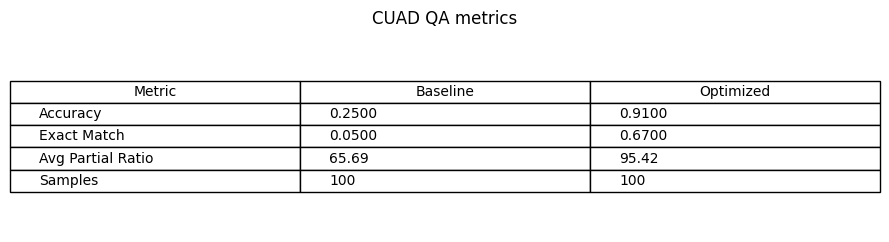

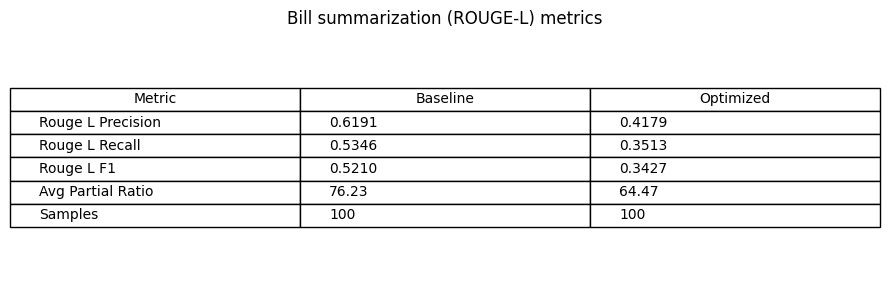

In [14]:
# Example (two separate comparisons, two result *types*):
plot_results_table(
    baseline_cuad_result,
    optimized_cuad_result,
    label_a="Baseline",
    label_b="Optimized",
    title="CUAD QA metrics",
)
plot_results_table(
    baseline_bill_sum_result,
    optimized_bill_sum_result,
    label_a="Baseline",
    label_b="Optimized",
    title="Bill summarization (ROUGE-L) metrics",
)